#XỬ LÝ DỮ LIỆU

In [ ]:
# Cài đặt thư viện
!pip install emoji pyvi symspellpy underthesea

import re
import pandas as pd
import emoji
from unicodedata import normalize
from pyvi import ViTokenizer
from underthesea import text_normalize
from symspellpy import SymSpell, Verbosity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.5 MB/s eta 0:00:00


In [ ]:
#imprort file
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/NLP/ĐỒ ÁN CUỐI KỲ_NLP_NHOM6/Source code/tat_ca_review_khach_san Agoda.csv', encoding='utf-16')
print(df.head())

                          Hotel                  Rating  \
0  KHÁCH SẠN THE MYST ĐỒNG KHỞI  10,0 Trên cả tuyệt vời   
1  KHÁCH SẠN THE MYST ĐỒNG KHỞI  10,0 Trên cả tuyệt vời   
2  KHÁCH SẠN THE MYST ĐỒNG KHỞI   9,6 Trên cả tuyệt vời   
3  KHÁCH SẠN THE MYST ĐỒNG KHỞI   9,2 Trên cả tuyệt vời   
4  KHÁCH SẠN THE MYST ĐỒNG KHỞI             7,6 Rất tốt   

                                             Content  
0  “Trên cả tuyệt vời” Cách phố đi bộ Nguyễn Huệ ...  
1  “Khách sạn tuyệt vời” Tôi đã có chuyến đi tuần...  
2  “Căn cứ tuyệt vời tại quận 1, TP. HCM” Một khá...  
3  “Cảm thấy thật được chiều chuộng ở đây!” Chúng...  
4  “Hãy chắc chắn rằng bạn nhận được những gì bạn...  


In [ ]:
# --- KHỞI TẠO SYMSPELL ---
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
sym_spell.load_dictionary('/content/drive/MyDrive/NLP/ĐỒ ÁN CUỐI KỲ_NLP_NHOM6/Source code/Viet74K.txt', term_index=0, count_index=1)

# Từ điển sửa lỗi thủ công (Xử lý các ca mà máy thường sửa sai do tần suất thấp)
custom_typo_map = {
    # Viết tắt chung
    "ks": "khách sạn", "kỳ nghi": "kỳ nghỉ", "nv": "nhân viên", "dv": "dịch_vụ", "đc": "được", "dc": "được", "ks,": "khách sạn",
    "st": "siêu_thị", "p": "phòng", "ph": "phòng", "tp": "thành_phố", "gđ": "gia_đình", "chải sản": "hải sản", "nhũng": "những", "san": "khách sạn",
    "ksan":"khách sạn", "nhan viên":"nhân viên",
    # Phủ định
    "ko": "không", "k": "không", "kh": "không", "hok": "không", "hông": "không",
    "chả": "không", "chẳng": "không",
    # Đánh giá & Cảm xúc
    "ok": "tốt", "oke": "tốt", "okie": "tốt", "bt": "bình_thường", "bth": "bình_thường", "tks": "cảm ơn",
    "view": "tầm_nhìn", "feedback": "phản_hồi", "r": "rồi", "rùi": "rồi", "v": "vậy", "good":'tốt',"5": "5 sao",
    # Cơ sở vật chất
    "wc": "nhà_vệ_sinh","tv": "ti vi", "vs": "vệ_sinh", "đh": "điều_hòa", "buffet": "bữa_sáng",
    # Địa danh
    "hcm": "hồ_chí_minh", "tsn": "Tân Sơn Nhất", "sg": "sài_gòn", "hn": "hà_nội", "đn": "đà_nẵng", "bắc địa": "đắc địa", "mai morse": "mai house"
}

# XỬ LÝ STOPWORDS
# Đọc file và loại bỏ các từ mang sắc thái biểu cảm/phủ định khỏi danh sách xóa
with open('/content/drive/MyDrive/NLP/ĐỒ ÁN CUỐI KỲ_NLP_NHOM6/Source code/vietnamese-stopwords.txt', 'r', encoding='utf-8') as f:
    base_stopwords = set(f.read().splitlines())

# Danh sách từ CẦN GIỮ LẠI để tránh mất nghĩa (Sentiment)
keep_words = {
'không', 'chưa', 'chẳng', 'tuyệt_vời', 'hài_lòng',
'nhưng', 'tệ', 'kém', 'đắt', 'rẻ', 'ổn', 'thích',
'cách', 'gần', 'xa', 'được', 'không_được','lần'
}
final_stopwords = base_stopwords - keep_words

In [ ]:
!pip install langdetect
from langdetect import detect, DetectorFactory
# Giúp kết quả detect ổn định hơn
DetectorFactory.seed = 0

In [ ]:
# NHÓM 1: LÀM SẠCH THÔ (Xử lý định dạng rác)
#Trích xuất Ngày tháng năm
def clean_date(date_text):
    if not isinstance(date_text, str): return ""
    match = re.search(r'(\d{1,2}\s+tháng\s+\d{1,2}\s+\d{4})', date_text)
    return match.group(1).strip() if match else ""

def remove_quoted_text(text):
    #Loại bỏ nội dung trong ngoặc kép (tiêu đề bị lặp lại)
    if not isinstance(text, str): return ""
    # Xử lý cả ngoặc kép thẳng và ngoặc kép cong
    clean_text = re.sub(r'[“"‟”].*?[“"‟”]', '', text)
    return re.sub(r'\s+', ' ', clean_text).strip()

def is_vietnamese_refined(text, threshold=0.01):
    if not isinstance(text, str) or len(text) < 2: return False
    vietnamese_chars = set("àáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵđ")
    text_lower = text.lower()
    viet_count = sum(1 for char in text_lower if char in vietnamese_chars)
# Nếu câu cực ngắn (dưới 15 ký tự) mà có ít nhất 1 dấu -> Giữ lại luôn
    if len(text_lower) < 15 and viet_count >= 1: return True
    return (viet_count / len(text_lower)) >= threshold

def language_filter(text):
    if not isinstance(text, str) or len(text.strip()) < 2: return False

    text_lower = text.lower()
    viet_chars = set("àáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵđ")
    has_viet_char = any(c in text_lower for c in viet_chars)

    # 1. Nếu có dấu tiếng Việt -> Tạm tin là tiếng Việt (giảm phụ thuộc langdetect)
    if has_viet_char: return True

    # 2. Nếu không có dấu, mới dùng langdetect để kiểm tra
    try:
        lang = detect(text_lower)
        if lang == 'vi': return True
        # Nếu là 'en' nhưng câu quá ngắn, có thể là ko dấu, ta vẫn nên cân nhắc giữ hoặc loại
        if lang != 'vi' and len(text_lower) > 30: return False
    except: pass

    return True # Mặc định giữ lại để tránh lọc quá đà


# NHÓM 2: LÀM SẠCH SÂU (Xử lý NLP)
def deep_clean_nlp(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""

    # 1. Chuẩn hóa & Phục hồi dấu (CỨU REVIEW KHÔNG DẤU)
    text = normalize('NFC', text.lower())
    try:
        text = text_normalize(text)
    except: pass

    # 2. Sửa lỗi viết tắt (ks -> khách sạn)
    words = text.split()
    words = [custom_typo_map.get(w, w) for w in words]

    # 3. Sửa lỗi chính tả SymSpell
    corrected_words = []
    for w in words:
        if w in custom_typo_map.values(): # Bỏ qua nếu đã sửa ở bước trên
            corrected_words.append(w)
            continue
        suggestions = sym_spell.lookup(w, Verbosity.TOP, max_edit_distance=1)
        corrected_words.append(suggestions[0].term if suggestions else w)
    text = " ".join(corrected_words)

    # 4. Xóa Emoji & Ký tự đặc biệt
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'[^a-z0-9àáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵđ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Tách từ & Lọc Stopwords
    text_tokenized = ViTokenizer.tokenize(text)
    final_words = [w for w in text_tokenized.split() if w not in final_stopwords]

    return " ".join(final_words)

#THỰC THI PIPELINE
# BƯỚC 1: XỬ LÝ THÔ
df['Score'] = df['Rating'].str.extract(r'^([\d,.]+)').fillna("0")
df['Review_Date'] = df['Content'].apply(clean_date)
df['Review_Body'] = df['Content'].apply(lambda x: str(x).split("Đã nhận xét vào")[0].strip())
df['Review_No_Quotes'] = df['Review_Body'].apply(remove_quoted_text)

# BƯỚC 2: LỌC NGÔN NGỮ (QUAN TRỌNG: Lọc TRƯỚC khi làm sạch sâu)
print("Đang lọc bỏ tiếng nước ngoài...")
# Sử dụng language_filter để loại bỏ "the room is clean" trước khi nó bị biến thành "thế..."
df_vn = df[df['Review_No_Quotes'].apply(language_filter)].copy()

# BƯỚC 3: LÀM SẠCH SÂU (NLP)
print("Đang tiến hành làm sạch sâu và phục hồi dấu...")
df_vn['Review_Final'] = df_vn['Review_No_Quotes'].apply(deep_clean_nlp)

# BƯỚC 4: LỌC LẠI LẦN CUỐI (Để loại bỏ những câu rác phát sinh sau NLP)
# Kiểm tra tỷ lệ dấu sau khi đã phục hồi dấu
result = df_vn[df_vn['Review_Final'].apply(lambda x: is_vietnamese_refined(x, threshold=0.1))].copy()

# BƯỚC 5: CHỐT DỮ LIỆU
result = result[['Hotel', 'Score', 'Review_Date', 'Review_Final']]
result = result[result['Review_Final'] != ""]

#THỐNG KÊ
print(f"Số lượng dòng ban đầu: {len(df)}")
print(f"Số lượng dòng sau khi làm sạch: {len(result)}")
print(f"Đã loại bỏ: {len(df) - len(result)} dòng không phải tiếng Việt hoặc rỗng.")

# Xuất file
result.to_csv('cleaned_data.csv', index=False, encoding='utf-8-sig')
result.head()

Đang lọc bỏ tiếng nước ngoài...
Đang tiến hành làm sạch sâu và phục hồi dấu...
Số lượng dòng ban đầu: 77783
Số lượng dòng sau khi làm sạch: 6818
Đã loại bỏ: 70965 dòng không phải tiếng Việt hoặc rỗng.


,Hotel,Score,Review_Date,Review_Final
0,KHÁCH SẠN THE MYST ĐỒNG KHỞI,"10,0",19 tháng 7 2025,cách phố đi nguyễn huệ 200 m vincom đồng_khởi ...
1,KHÁCH SẠN THE MYST ĐỒNG KHỞI,"10,0",13 tháng 7 2025,chuyến đi tuần_trăng_mật không_thể khen khách_...
2,KHÁCH SẠN THE MYST ĐỒNG KHỞI,"9,6",03 tháng 7 2025,khách_sạn không_khí boutique dễ_thương vị_trí ...
3,KHÁCH SẠN THE MYST ĐỒNG KHỞI,"9,2",03 tháng 7 2025,chúng_tôi kỳ nghỉ dễ_chịu the myst vị_trí tuyệ...
4,KHÁCH SẠN THE MYST ĐỒNG KHỞI,"7,6",29 tháng 6 2025,vợ_chồng phòng chúng_tôi tình_cờ chính_xác phò...


#GÁN NHÃN DỮ LIỆU

In [ ]:
#Thực hiện gán nhãn cảm xúc dựa trên Score
def label_sentiment(score):
    try:
        # Chuyển đổi dấu phẩy thành dấu chấm để ép kiểu float
        s = float(str(score).replace(',', '.'))
        if s > 8.0:
            return "Tích cực"
        elif s >= 6.0:
            return "Trung lập"
        else:
            return "Tiêu cực"
    except:
        return "Trung lập"

# Áp dụng gán nhãn
result['Sentiment'] = result['Score'].apply(label_sentiment)

print("Phân bổ nhãn cảm xúc:")
print(result['Sentiment'].value_counts())

# # Lưu kết quả
result[['Hotel', 'Score', 'Sentiment', 'Review_Final']].to_csv('data_nlp_ready.csv', index=False, encoding='utf-8-sig')
print("Hoàn thành! File đã sẵn sàng cho Model.")
result.head()

Phân bổ nhãn cảm xúc:
Sentiment
Tích cực     4892
Trung lập    1365
Tiêu cực      561
Name: count, dtype: int64
Hoàn thành! File đã sẵn sàng cho Model.


,Hotel,Score,Review_Date,Review_Final,Sentiment
0,KHÁCH SẠN THE MYST ĐỒNG KHỞI,"10,0",19 tháng 7 2025,cách phố đi nguyễn huệ 200 m vincom đồng_khởi ...,Tích cực
1,KHÁCH SẠN THE MYST ĐỒNG KHỞI,"10,0",13 tháng 7 2025,chuyến đi tuần_trăng_mật không_thể khen khách_...,Tích cực
2,KHÁCH SẠN THE MYST ĐỒNG KHỞI,"9,6",03 tháng 7 2025,khách_sạn không_khí boutique dễ_thương vị_trí ...,Tích cực
3,KHÁCH SẠN THE MYST ĐỒNG KHỞI,"9,2",03 tháng 7 2025,chúng_tôi kỳ nghỉ dễ_chịu the myst vị_trí tuyệ...,Tích cực
4,KHÁCH SẠN THE MYST ĐỒNG KHỞI,"7,6",29 tháng 6 2025,vợ_chồng phòng chúng_tôi tình_cờ chính_xác phò...,Trung lập


#EDA

TF-IDF trên 3 nhãn cảm xúc

--- Top 5 từ ghép [Tích cực] ---
           Word  TF-IDF Sum
489   khách_sạn  365.652441
819       phòng  307.721178
733   nhân_viên  286.224258
1159  tuyệt_vời  276.406845
956     sạch_sẽ  255.604065 

--- Top 5 từ ghép [Tiêu cực] ---
          Word  TF-IDF Sum
223      không   69.171005
342      phòng   51.587586
219  khách_sạn   41.524149
311  nhân_viên   37.775014
502         tệ   22.022832 

--- Top 5 từ ghép [Trung lập] ---
          Word  TF-IDF Sum
596      phòng  106.651490
364      không  100.294571
357  khách_sạn   96.352207
926     vị_trí   70.030106
540  nhân_viên   69.359719 



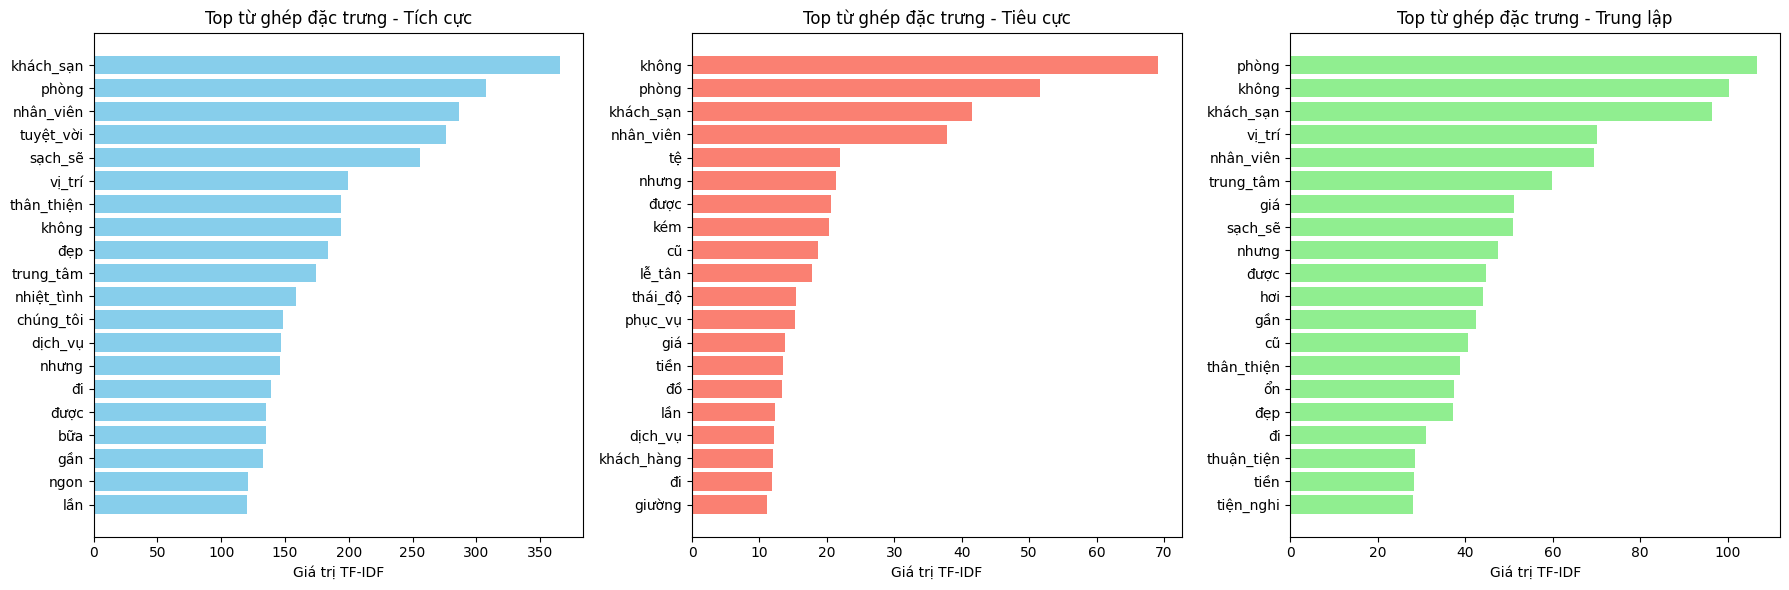

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Giả sử tập dữ liệu của bạn có cột 'Sentiment' chứa 3 nhãn: 'Tích cực', 'Tiêu cực', 'Trung lập'
# Nhớ thay đổi tên cột 'Sentiment' thành tên cột nhãn thực tế của bạn
labels = ['Tích cực', 'Tiêu cực', 'Trung lập']
colors = ['skyblue', 'salmon', 'lightgreen']

# Biểu thức chính quy CHỈ bắt các từ có ít nhất một dấu gạch dưới '_' (từ ghép)
# VD: "giao_hàng", "rất_tốt", "nhân_viên_thân_thiện"
compound_word_pattern = r'(?u)\b\w+_[_\w]+\b'

# Tạo figure để vẽ 3 biểu đồ con cạnh nhau
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, label in enumerate(labels):
    # 1. Lọc text theo nhãn cảm xúc từ dataframe gốc
    # (Bạn có thể dùng tập X_train nếu đã join lại với y_train, ở đây tôi dùng thẳng trên 'result')
    subset_text = result[result['Sentiment'] == label]['Review_Final']

    # Bỏ qua nếu nhãn không có dữ liệu
    if len(subset_text) == 0:
        continue

    # 2. Cài đặt TF-IDF chỉ lấy từ ghép
    vectorizer = TfidfVectorizer(
        max_features=1500, # Giảm max_features xuống một chút vì chỉ lấy từ ghép
        token_pattern=r'(?u)\b[a-zA-ZÀ-ỹ]+(?:_[a-zA-ZÀ-ỹ]+)*\b',
        min_df=3,
        max_df=0.8
    )


    # Fit và transform
    X_tfidf = vectorizer.fit_transform(subset_text)

    # 3. Tính độ quan trọng
    feature_names = vectorizer.get_feature_names_out()
    tfidf_sum = X_tfidf.toarray().sum(axis=0)

    tfidf_sum_df = pd.DataFrame({'Word': feature_names, 'TF-IDF Sum': tfidf_sum})
    tfidf_sum_df = tfidf_sum_df.sort_values(by="TF-IDF Sum", ascending=False)

    # 4. Vẽ biểu đồ (Top 20 từ cho mỗi nhãn)
    top_20 = tfidf_sum_df.head(20).iloc[::-1] # Đảo ngược để vẽ chart ngang (từ cao nhất ở trên cùng)

    ax = axes[i]
    # plt.barh(top_20['Word'], top_20['TF-IDF Sum'], color='skyblue')
    ax.barh(top_20['Word'], top_20['TF-IDF Sum'], color=colors[i])
    ax.set_title(f'Top từ ghép đặc trưng - {label}')
    ax.set_xlabel('Giá trị TF-IDF')

    # In kết quả ra console
    print(f"--- Top 5 từ ghép [{label}] ---")
    print(tfidf_sum_df.head(), "\n")

# Canh chỉnh khoảng cách giữa các biểu đồ và hiển thị
plt.tight_layout()
plt.show()

#Word Cloud

In [ ]:
!pip install wordcloud

word clouds trên toàn bộ tập dữ liệu

Đang phân tích và vẽ đám mây từ cho toàn bộ tập dữ liệu...


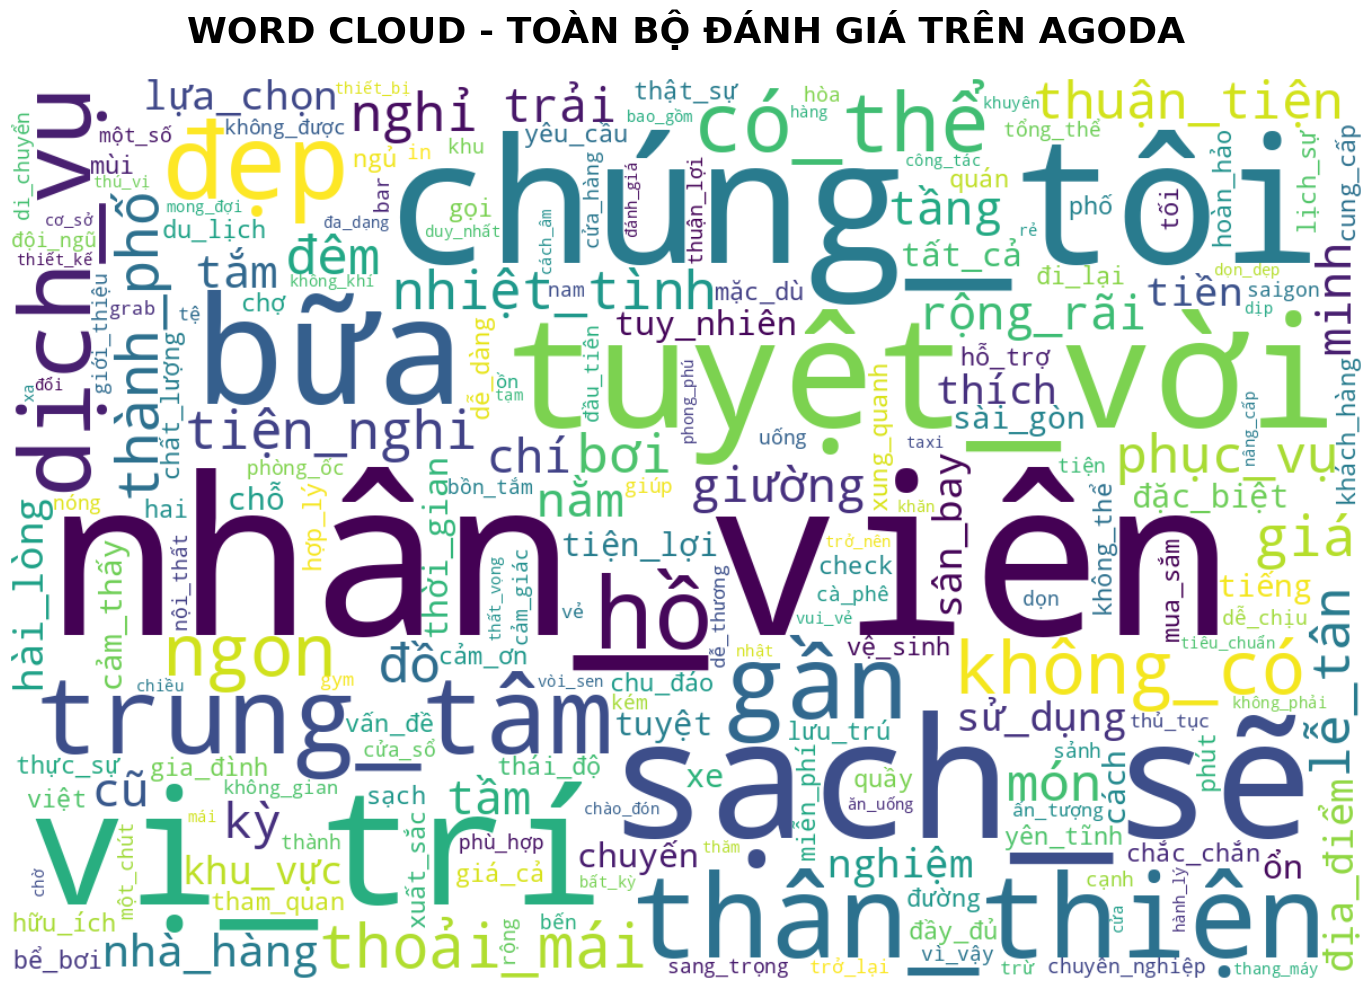

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def draw_overall_wordcloud(df):
    # Kết hợp toàn bộ văn bản từ cột 'Review_Final', loại bỏ các giá trị rỗng nếu có
    text = " ".join(str(review) for review in df['Review_Final'].dropna())

    if text.strip() == "":
        print("Không có dữ liệu để vẽ Word Cloud.")
        return

    # Tạo WordCloud cho toàn bộ tập dữ liệu
    wordcloud = WordCloud(
        width=1200,           # Tăng kích thước chiều rộng
        height=800,           # Tăng kích thước chiều cao
        background_color='white',
        stopwords=final_stopwords, # Giữ nguyên danh sách stopwords của bạn
        colormap='viridis',   # Thang màu tổng quát đẹp mắt (bạn có thể đổi thành 'Blues', 'magma'...)
        max_words=200,        # Tăng số lượng từ tối đa vì đây là toàn bộ data
        collocations=False    # Tránh lặp cụm từ
    ).generate(text)

    # Cài đặt khung hình và vẽ
    plt.figure(figsize=(16, 10))
    plt.imshow(wordcloud, interpolation='bilinear')

    # Tiêu đề biểu đồ
    plt.title('WORD CLOUD - TOÀN BỘ ĐÁNH GIÁ TRÊN AGODA', fontsize=26, fontweight='bold', pad=25)
    plt.axis("off")

    plt.tight_layout()
    # Lưu ảnh với độ phân giải cao để chèn vào báo cáo
    plt.savefig('overall_agoda_wordcloud.png', dpi=300)
    plt.show()

# Gọi hàm để thực thi
print("Đang phân tích và vẽ đám mây từ cho toàn bộ tập dữ liệu...")
draw_overall_wordcloud(result)

CHART PHÂN BỐ NHÃN CẢM XÚC

/tmp/ipykernel_1090/3841845080.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=result, x='Sentiment', palette=colors, order=order)


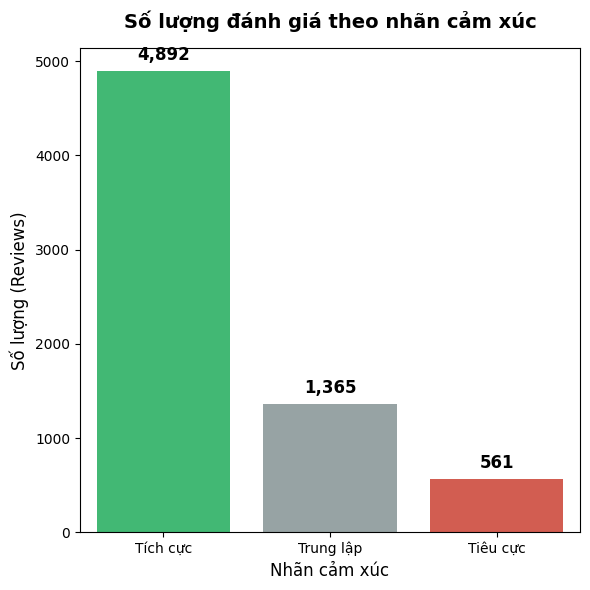

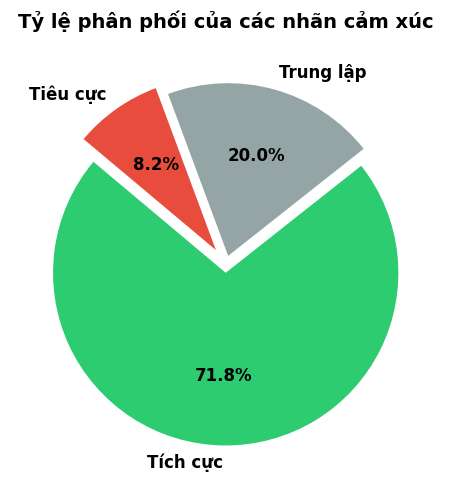

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập font chữ mặc định để không bị lỗi tiếng Việt
plt.rcParams['font.family'] = 'sans-serif'

# Định nghĩa màu sắc và thứ tự cho 3 nhãn (Xanh lá - Xám - Đỏ)
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
order = ['Tích cực', 'Trung lập', 'Tiêu cực']

# ==========================================
# BIỂU ĐỒ 1: BIỂU ĐỒ CỘT (Đếm số lượng thực tế)
# ==========================================
plt.figure(figsize=(6, 6))
ax = sns.countplot(data=result, x='Sentiment', palette=colors, order=order)
plt.title('Số lượng đánh giá theo nhãn cảm xúc', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nhãn cảm xúc', fontsize=12)
plt.ylabel('Số lượng (Reviews)', fontsize=12)

# Ghi số liệu lên đầu mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show() # Hiển thị Biểu đồ 1


# ==========================================
# BIỂU ĐỒ 2: BIỂU ĐỒ TRÒN (Tỷ lệ phần trăm)
# ==========================================
plt.figure(figsize=(5, 5))
sentiment_counts = result['Sentiment'].value_counts()[order]

plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=(0.05, 0.05, 0.1), # Tách nhẹ lát cắt "Tiêu cực" ra để nhấn mạnh
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Tỷ lệ phân phối của các nhãn cảm xúc', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show() # Hiển thị Biểu đồ 2

PHÂN BỔ CHART THEO RATING

/tmp/ipykernel_1090/1540314085.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_filtered, x='Rounded_Score', palette=colors)
/tmp/ipykernel_1090/1540314085.py:33: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  ax = sns.countplot(data=df_filtered, x='Rounded_Score', palette=colors)


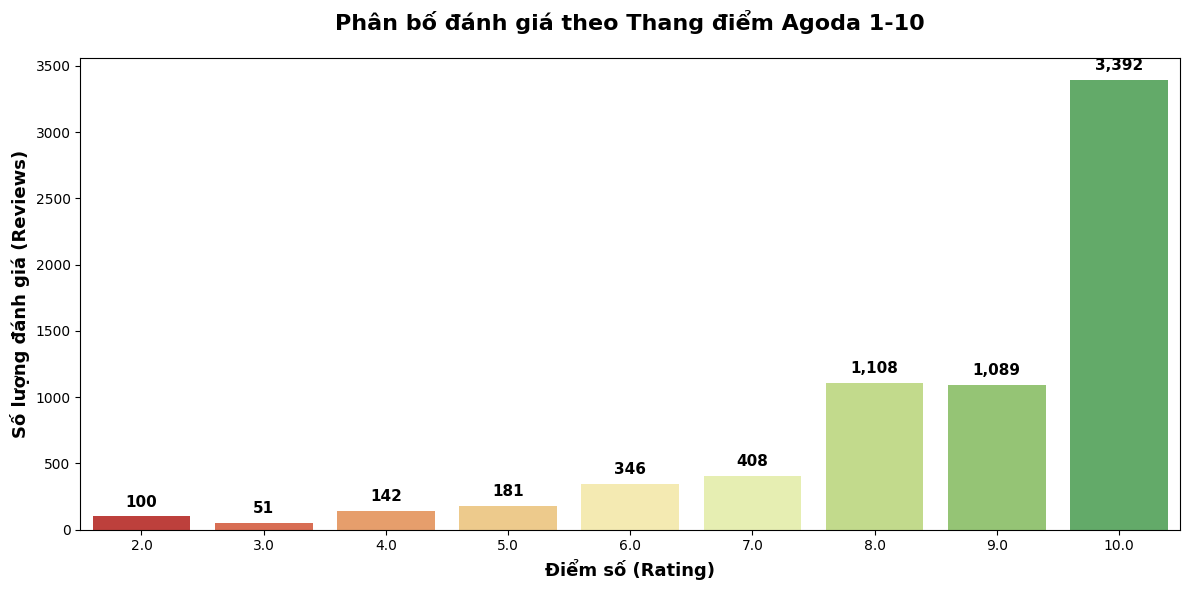

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập font chữ mặc định cho biểu đồ
plt.rcParams['font.family'] = 'sans-serif'

# 2. Xử lý cột điểm số (Score)
# Chuyển đổi định dạng dấu phẩy (vd: "9,6") thành dấu chấm và ép kiểu số thực (float)
def clean_score(x):
    try:
        return float(str(x).replace(',', '.'))
    except:
        return None

result['Numeric_Score'] = result['Score'].apply(clean_score)

# 3. PHÂN NHÓM ĐIỂM SỐ (LÀM TRÒN)
# Sử dụng hàm round() để đưa điểm số về các mức 1, 2, 3... 10
# Ví dụ: 9.6 -> 10.0; 8.4 -> 8.0
df['Rounded_Score'] = result['Numeric_Score'].round().astype(int)

# Giới hạn chỉ lấy các điểm hợp lệ từ 1 đến 10
df_filtered = df[(df['Rounded_Score'] >= 1) & (df['Rounded_Score'] <= 10)]

# 4. VẼ BIỂU ĐỒ CỘT (BAR CHART)
plt.figure(figsize=(12, 6))

# Định nghĩa bảng màu gradient trực quan (từ đỏ/cam sang xanh lá)
colors = sns.color_palette("RdYlGn", 10)

ax = sns.countplot(data=df_filtered, x='Rounded_Score', palette=colors)

plt.title('Phân bố đánh giá theo Thang điểm Agoda 1-10', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Điểm số (Rating)', fontsize=13, fontweight='bold')
plt.ylabel('Số lượng đánh giá (Reviews)', fontsize=13, fontweight='bold')

# Thêm nhãn số lượng chi tiết lên đầu mỗi cột
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Chỉ in số trên các cột có dữ liệu
        ax.annotate(f'{int(height):,}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold',
                    xytext=(0, 5), textcoords='offset points')

# Căn chỉnh và lưu biểu đồ
plt.tight_layout()
plt.savefig('bieu_do_phan_bo_diem_so.png', dpi=300, bbox_inches='tight')
plt.show()

MỐI QUAN HỆ GIỮA RATING VÀ CẢM XÚC

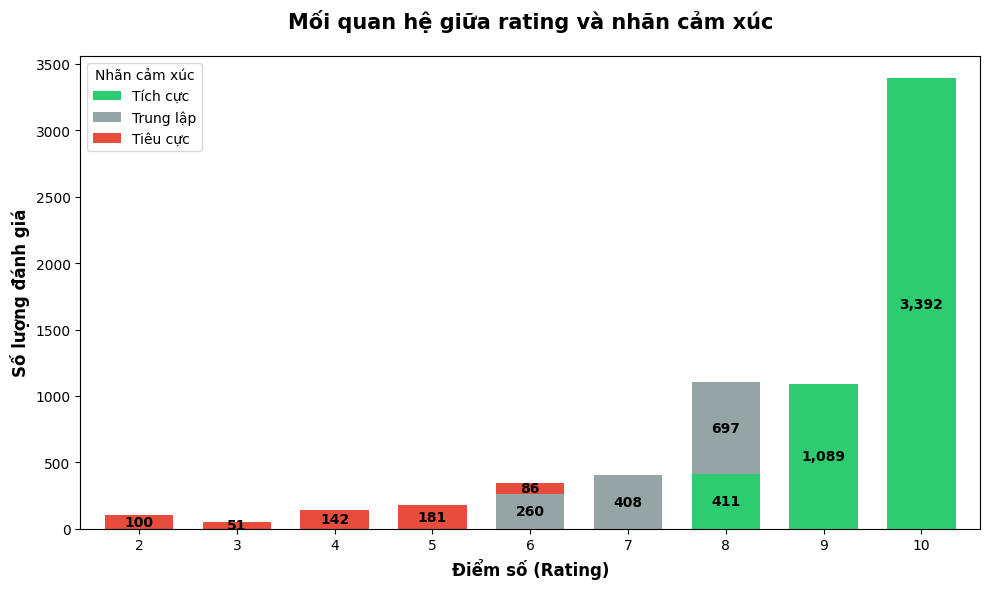

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Thiết lập font chữ mặc định
plt.rcParams['font.family'] = 'sans-serif'

def clean_score_strict(x):
    if pd.isna(x):
        return np.nan
    try:
        return float(str(x).strip().replace(',', '.'))
    except ValueError:
        return np.nan

result['Numeric_Score'] = result['Score'].apply(clean_score_strict)
df = result.dropna(subset=['Numeric_Score', 'Sentiment'])

# Làm tròn điểm từ 1 đến 10
df['Rounded_Score'] = result['Numeric_Score'].round().astype(int)
df_filtered = df[(df['Rounded_Score'] >= 1) & (df['Rounded_Score'] <= 10)]

# 2. CHUẨN BỊ DỮ LIỆU CHO CỘT CHỒNG
# Tạo bảng chéo (Pivot table) đếm số lượng theo điểm và nhãn
order = ['Tích cực', 'Trung lập', 'Tiêu cực']
colors = ['#2ecc71', '#95a5a6', '#e74c3c']

pivot_df = df_filtered.groupby(['Rounded_Score', 'Sentiment']).size().unstack(fill_value=0)
# Sắp xếp lại thứ tự cột cho đúng với màu sắc: Xanh - Xám - Đỏ
pivot_df = pivot_df.reindex(columns=order)

# 3. VẼ BIỂU ĐỒ CỘT CHỒNG (STACKED BAR CHART)
fig, ax = plt.subplots(figsize=(10, 6))

pivot_df.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.7)

plt.title('Mối quan hệ giữa rating và nhãn cảm xúc', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Điểm số (Rating)', fontsize=12, fontweight='bold')
plt.ylabel('Số lượng đánh giá', fontsize=12, fontweight='bold')
plt.legend(title='Nhãn cảm xúc', loc='upper left')

# Xoay nhãn trục X nằm ngang cho dễ đọc
plt.xticks(rotation=0)

# 4. GHI SỐ LIỆU VÀO GIỮA CÁC ĐOẠN CỘT
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()

    # Chỉ ghi số nếu đoạn cột có dữ liệu (chiều cao > 0)
    if height > 0:
        ax.text(x + width/2,
                y + height/2,
                f'{int(height):,}',
                ha='center',
                va='center',
                color='black',
                fontsize=10,
                fontweight='bold')

plt.tight_layout()
plt.show()

DỮ LIỆU SAU CÂN BẰNG SMOTE

In [ ]:
!pip install pandas scikit-learn imbalanced-learn matplotlib

PHÂN PHỐI NHÃN SAU CẦN BẰNG

Đang đọc dữ liệu từ data_nlp_ready.csv...

--- SỐ LƯỢNG NHÃN TRƯỚC KHI CÂN BẰNG ---
Sentiment
Tích cực     4892
Trung lập    1365
Tiêu cực      561
Name: count, dtype: int64

Đang tiến hành chuyển đổi văn bản thành vector bằng TF-IDF...
Đang tiến hành chạy SMOTE...

--- SỐ LƯỢNG NHÃN SAU KHI CÂN BẰNG (SMOTE) ---
Sentiment
Tích cực     4892
Trung lập    4892
Tiêu cực     4892
Name: count, dtype: int64


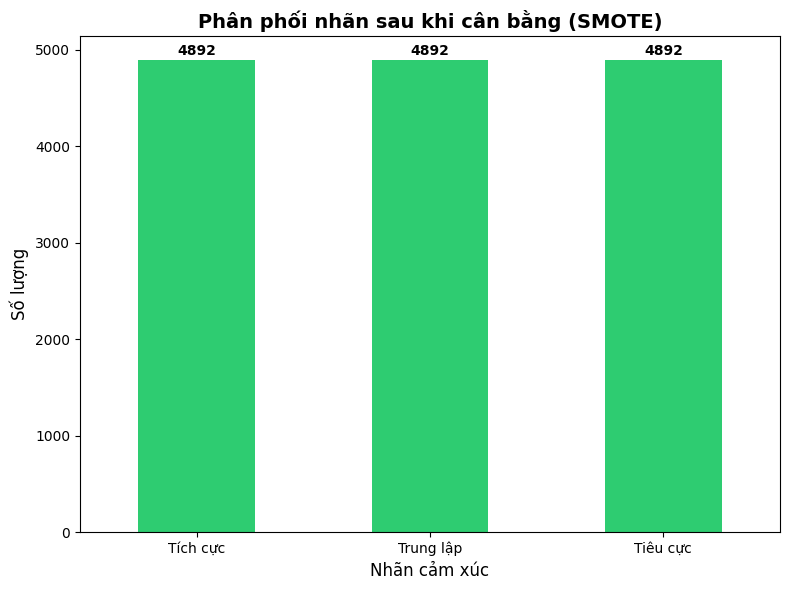


=> Dữ liệu đã được cân bằng thành công. Bây giờ X_resampled và y_resampled đã sẵn sàng để train AI!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

# ==========================================
# BƯỚC 1: Đọc và kiểm tra dữ liệu
# ==========================================
print("Đang đọc dữ liệu từ data_nlp_ready.csv...")
df = result.dropna(subset=['Review_Final', 'Sentiment']) # Làm sạch dữ liệu rỗng

# Hiển thị số lượng nhãn trước khi cân bằng
label_counts_before = result['Sentiment'].value_counts()
print("\n--- SỐ LƯỢNG NHÃN TRƯỚC KHI CÂN BẰNG ---")
print(label_counts_before)

# ==========================================
# BƯỚC 2: Chuyển văn bản thành Vector (TF-IDF)
# ==========================================
print("\nĐang tiến hành chuyển đổi văn bản thành vector bằng TF-IDF...")
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['Review_Final'])
y = df['Sentiment']

# ==========================================
# BƯỚC 3: Áp dụng thuật toán SMOTE
# ==========================================
print("Đang tiến hành chạy SMOTE...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# ==========================================
# BƯỚC 4: Kết quả và Chart SAU KHI CÂN BẰNG
# ==========================================
y_resampled_series = pd.Series(y_resampled)
label_counts_after = y_resampled_series.value_counts()
print("\n--- SỐ LƯỢNG NHÃN SAU KHI CÂN BẰNG (SMOTE) ---")
print(label_counts_after)

# Vẽ biểu đồ kết quả sau SMOTE
plt.figure(figsize=(8, 6))
bars = label_counts_after.plot(kind='bar', color=['#2ecc71', '#2ecc71', '#2ecc71'])
plt.title('Phân phối nhãn sau khi cân bằng (SMOTE)', fontsize=14, fontweight='bold')
plt.xlabel('Nhãn cảm xúc', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=0)

# Hiển thị số lượng trực tiếp trên từng cột của biểu đồ
for i, v in enumerate(label_counts_after):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=> Dữ liệu đã được cân bằng thành công. Bây giờ X_resampled và y_resampled đã sẵn sàng để train AI!")